Adapted from https://github.com/cortes-ciriano-lab/lta-analysis 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Find the number of TP53 upstream hotspot samples, the percentage of those that are interchromosomal (connected to / not connected to another hotspot)
final_analysis_samples = pd.read_csv('../../../SV_sample_data/data/final_analysis_samples.csv')

events = pd.read_csv('../results/final_clustered_sv_events.csv')
events = events[events['sample'].isin(final_analysis_samples['tumor_normal_pair'])]
tp53_events = events[events['TP53'] == 1]

# There are 2 TP53 events from sample SA541936-SA541937, exclude event from this sample with n_clusters = 1
event_to_exclude = tp53_events[tp53_events['sample'] == "SA541936-SA541937"]
event_to_exclude = event_to_exclude[event_to_exclude['n_clusters'] == 1]
tp53_events = tp53_events[~tp53_events['event_idx'].isin(event_to_exclude['event_idx'])]

print("Number of TP53 upstream hotspot samples:", len(tp53_events['sample'].unique()))

# number and % of interchromosomal tp53 events
tp53_interchr = tp53_events[tp53_events['is_inter_chr']]
print(f"Number of interchromosomal TP53 events: {len(tp53_interchr)}, {(len(tp53_interchr) / len(tp53_events) * 100):.2f} %")
n_inter = len(tp53_interchr)

# number and % of interchromosomal tp53 events that involve other hotspots
other_hotspots = ['CCND3', 'MYC', 'CDK4-MDM2', 'CCNE1']
tp53_events['connected_other_hotspot'] = tp53_events[other_hotspots].sum(axis=1) > 0 
n_connected = tp53_events['connected_other_hotspot'].sum()
n_not_connected = n_inter - n_connected
print(f"    Connected to another hotspot: {n_connected}, {(n_connected / n_inter * 100):.2f} %")
print(f"    Not connected to another hotspot: {n_not_connected}, {(n_not_connected / n_inter * 100):.2f} %")

Number of TP53 upstream hotspot samples: 51
Number of interchromosomal TP53 events: 41, 80.39 %
    Connected to another hotspot: 24, 58.54 %
    Not connected to another hotspot: 17, 41.46 %


In [3]:
tp53_events.head(5)

,event_idx,sample,n_chromosomes,chromosomes,n_clusters,source_clusters,component_events,is_inter_chr,CCND3,MYC,CDK4-MDM2,CCNE1,TP53,connected_other_hotspot
21,21,24T02-24N02,2,"['15', '17']",2,"['24T02-24N02_15_72073950_98108012', '24T02-24...","['24T02-24N02_15_72073950_98108012', '24T02-24...",True,0,0,0,0,1,False
23,24,39T01-39N01,2,"['6', '17']",2,"['39T01-39N01_17_8706612_19626623', '39T01-39N...","['39T01-39N01_17_8706612_19626623', '39T01-39N...",True,0,0,0,0,1,False
35,35,CCG1106_005_T1-CCG1106_005_WB,8,"['1', '5', '9', '11', '12', '15', '17', '20']",15,['CCG1106_005_T1-CCG1106_005_WB_11_77290949_79...,['CCG1106_005_T1-CCG1106_005_WB_11_77290949_79...,True,0,0,0,0,1,False
39,39,CCG1106_075_T1-CCG1106_075_WB,2,"['13', '17']",3,['CCG1106_075_T1-CCG1106_075_WB_13_110234722_1...,['CCG1106_075_T1-CCG1106_075_WB_13_69749803_11...,True,0,0,0,0,1,False
45,45,CCG1106_086_T1-CCG1106_086_WB,4,"['1', '2', '6', '17']",6,['CCG1106_086_T1-CCG1106_086_WB_17_7735383_917...,['CCG1106_086_T1-CCG1106_086_WB_17_7735383_917...,True,1,0,0,0,1,True


In [4]:
tp53_status = pd.read_csv('../data/TP53_biallelic_status_mechanism.tsv', sep='\t')
tp53_status = tp53_status[tp53_status['Tumor_Sample_Barcode'].isin(final_analysis_samples['tumor_normal_pair'])]
print(tp53_status['TP53_Biallelic_Status'].value_counts())
tp53_status['TP53_Mechanism'].value_counts()

TP53_Biallelic_Status
Biallelic      130
No Hit          49
Monoallelic     28
Name: count, dtype: int64


TP53_Mechanism
LOH + SV                            62
No Hit                              49
Copy Loss (total_cn < 1.5) + SV     20
LOH + SNV                           20
Copy Loss (total_cn < 1.5)          14
Copy Loss (total_cn < 1.5) + SNV    12
SV only                             12
Deep Deletion                        7
CN-LOH + SNV                         5
CN-LOH + SV                          3
SNV only                             2
LOH + SNV + SV                       1
Name: count, dtype: int64

In [5]:
# load the CNV files
cnv = pd.read_hdf('../../../SV_sample_data/data/analysis_public_os_data_merged_abs_segfiles_v2.h5')
cnv = cnv[cnv['sample'].isin(final_analysis_samples['tumor_normal_pair'])]

Criteria:
* Biallelic _TP53_ disruption. 
* Connections between chromosome 17p and other chromosome arms with CGRs.
* Presence of an SV in the _TP53_ gene body, or a translocation breakpoint or a CGR in the region between start of _TP53_ and the centromere.
* Loss of the 17p terminal segment harbouring _TP53_: a  LOH in the 17p terminal segment, minimum of 75% LOH in the genomic region from the start of the chromosome up to and including _TP53_. 
* Alternatively: LOH in >33% of the terminal segment of 17p together with an amplification (minimum 1kbp of 9 copies or more)
* Absence of full chromosome LOH and chromosome arm LOH
* Removing cases where the chromosome (arm) shows extensive LOH (>90%) and exists in a single copy number state (>90%). This removes aneuploidies but does not discard extensive LOH due to rearrangements.
* Removing all cases with full chromosome arm LOH (>99.5%)


In [6]:
# LTA detection
TP53_START      = 7_668_421
TP53_END        = 7_687_490
CHR17_CENT      = 22_200_000
CHR17_LEN       = 83_257_441
LOH_THRESHOLD   = 0.2  # minor allele CN ≤ this = LOH

cnv['minor_cn'] = cnv[['rescaled.cn.a1', 'rescaled.cn.a2']].min(axis=1)
cnv['total_cn']  = cnv['rescaled.cn.a1'] + cnv['rescaled.cn.a2']
cnv['seg_len']   = cnv['End.bp'] - cnv['Start.bp']
cnv['is_loh']    = cnv['minor_cn'] <= LOH_THRESHOLD
cnv['Chromosome'] = cnv['Chromosome'].astype(str)

samples = tp53_events['sample'].unique()

def weighted_loh_fraction(segs):
    """Fraction of bp in LOH across a set of segments."""
    if segs.empty or segs['seg_len'].sum() == 0:
        return 0.0
    loh_bp = segs.loc[segs['is_loh'], 'seg_len'].sum()
    return loh_bp / segs['seg_len'].sum()

def single_cn_state_fraction(segs, threshold=0.90):
    """Fraction of bp dominated by one integer CN state."""
    if segs.empty:
        return 0.0
    segs = segs.copy()
    segs['cn_int'] = segs['total_cn'].round().astype(int)
    total_len = segs['seg_len'].sum()
    mode_len  = segs.groupby('cn_int')['seg_len'].sum().max()
    return mode_len / total_len

results = []

for sample in samples:

    row = {'sample': sample}
    s_cnv = cnv[cnv['sample'] == sample].copy()
    chr17 = s_cnv[s_cnv['Chromosome'].astype(str).isin(['17'])].copy()

    # Biallelic TP53 disruption
    row['biallelic_tp53'] = tp53_status.loc[tp53_status['Tumor_Sample_Barcode'] == sample, 'TP53_Biallelic_Status'].values[0] == 'Biallelic'
    row['monoallelic_tp53'] = tp53_status.loc[tp53_status['Tumor_Sample_Barcode'] == sample, 'TP53_Biallelic_Status'].values[0] == 'Monoallelic'

    # 17p terminal segment loss (start of the chromosome up to and including TP53)
    terminal = chr17[chr17['Start.bp'] <= TP53_END].copy()
    # clip segments that extend past TP53_END
    terminal['End.bp'] = terminal['End.bp'].clip(upper=TP53_END)
    terminal['seg_len'] = terminal['End.bp'] - terminal['Start.bp']
    terminal = terminal[terminal['seg_len'] > 0]
    terminal_loh_frac = weighted_loh_fraction(terminal)
    row['terminal_loh_frac'] = terminal_loh_frac
    # alternative: ≥33% LOH + any segment ≥9 copies ≥1kb
    has_high_amp = bool(terminal.loc[terminal['total_cn'] >= 9, 'seg_len'].sum() > 1_000_000)
    row['terminal_loss'] = ((terminal_loh_frac >= 0.75) or (terminal_loh_frac >= 0.33 and has_high_amp))

    # Exclusion of aneuploidies (might not need these criteria because these are anyways samples with clustered SVs around TP53)
    arm_17p = chr17[chr17['End.bp'] <= CHR17_CENT].copy()
    arm_loh_frac = weighted_loh_fraction(arm_17p)
    arm_cn_state = single_cn_state_fraction(arm_17p)
    full_loh_frac = weighted_loh_fraction(chr17)
    full_cn_state = single_cn_state_fraction(chr17)
    row['exclude_arm_loh_cn'] = (arm_loh_frac > 0.90 and arm_cn_state > 0.90)
    row['exclude_arm_loh_995'] = (arm_loh_frac >= 0.995)
    row['exclude_full_chr_loh'] = (full_loh_frac > 0.90 and full_cn_state > 0.90)
    row['excluded'] = row['exclude_arm_loh_cn'] or row['exclude_arm_loh_995'] or row['exclude_full_chr_loh']

    results.append(row)

lta_df = pd.DataFrame(results)
lta_df = lta_df.merge(
    tp53_events[['sample', 'connected_other_hotspot', 'is_inter_chr', 'CCND3', 'MYC', 'CDK4-MDM2', 'CCNE1']].drop_duplicates(),
    on='sample', how='left'
)
# Final LTA call
# lta_df['LTA'] = (lta_df['biallelic_tp53'] and lta_df['terminal_loss'] and not lta_df['excluded'])
lta_df['LTA'] = (lta_df['biallelic_tp53'] & lta_df['terminal_loss'] & lta_df['is_inter_chr']) 

print(f"LTA-positive samples: {lta_df['LTA'].sum()} / {len(lta_df['sample'].unique())}")
print(lta_df[lta_df['LTA']][['sample', 'biallelic_tp53', 'terminal_loh_frac', 'connected_other_hotspot']])
lta_df.to_csv('../results/lta_analysis.csv', index=False)

LTA-positive samples: 29 / 51
                                       sample  biallelic_tp53  \
0                                 24T02-24N02            True   
1                                 39T01-39N01            True   
2               CCG1106_005_T1-CCG1106_005_WB            True   
3               CCG1106_075_T1-CCG1106_075_WB            True   
8                           SA541906-SA541907            True   
10                          SA541936-SA541937            True   
12                  SAMN03223756-SAMN03223799            True   
13                  SAMN03223803-SAMN03223740            True   
14                SJOS001101_M7-SJOS001101_G1            True   
15                SJOS001107_D1-SJOS001107_G1            True   
19                SJOS001121_D2-SJOS001121_G1            True   
20                SJOS001132_M1-SJOS001132_G1            True   
21                        SJOS003_D-SJOS003_G            True   
22                        SJOS004_D-SJOS004_G            Tru

In [7]:
print("Filter breakdown:")
print(f"Total:                      {len(lta_df)}")
print(f"is_inter_chr:               {lta_df['is_inter_chr'].sum()}")
print(f"biallelic_tp53:             {lta_df['biallelic_tp53'].sum()}")
#print(f"  tp53_snv:                 {lta_df['tp53_snv'].sum()}")
#print(f"  tp53_sv_body:             {lta_df['tp53_sv_body'].sum()}")
#print(f"  tp53_loh:                 {lta_df['tp53_loh'].sum()}")
print(f"terminal_loss:              {lta_df['terminal_loss'].sum()}")
print(f"exclude_arm_loh_cn:         {lta_df['exclude_arm_loh_cn'].sum()}")
print(f"exclude_arm_loh_995:        {lta_df['exclude_arm_loh_995'].sum()}")
print(f"exclude_full_chr_loh:       {lta_df['exclude_full_chr_loh'].sum()}")
print()

step1 = lta_df['is_inter_chr']
step2 = step1 & lta_df['biallelic_tp53']
step3 = step2 & lta_df['terminal_loss']
step4 = step3 & ~lta_df['excluded']

print(f"After is_inter_chr:         {step1.sum()}")
print(f"After biallelic_tp53:       {step2.sum()}")
print(f"After terminal_loss:        {step3.sum()}")
#print(f"After exclusions:           {step4.sum()}")

Filter breakdown:
Total:                      51
is_inter_chr:               41
biallelic_tp53:             41
terminal_loss:              40
exclude_arm_loh_cn:         1
exclude_arm_loh_995:        4
exclude_full_chr_loh:       2

After is_inter_chr:         41
After biallelic_tp53:       33
After terminal_loss:        29


In [8]:
hotspot_lta = lta_df[lta_df['LTA'] & lta_df['connected_other_hotspot']]
hotspot_lta_samples = hotspot_lta['sample'].unique()
mask = tp53_interchr['sample'].isin(hotspot_lta_samples)
out = tp53_interchr.loc[mask, ['sample', 'chromosomes', 'component_events']].sort_values('sample')
print(out.to_string(index=False))

                                   sample                            chromosomes                                                                                                                                                                                                                                                                                                                                                                                                                                                                     component_events
                        SA541936-SA541937                ['3', '12', '15', '17']                                                                                                                                                                                                                                                                    ['SA541936-SA541937_12_65393064_98052849', 'SA541936-SA541937_15_57315117_58023966', 'SA541936-SA541937_17_109

In [9]:
# where are the connections if not to a hotspot for samples with LTA? 
non_hotspot_lta = lta_df[lta_df['LTA'] & ~lta_df['connected_other_hotspot']]
non_hotspot_lta_samples = non_hotspot_lta['sample'].unique()
mask = tp53_interchr['sample'].isin(non_hotspot_lta_samples)
out = tp53_interchr.loc[mask, ['sample', 'chromosomes', 'component_events']].sort_values('sample')
print(out.to_string(index=False))

                                   sample                                   chromosomes                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             component_events
                              24T02-24N02                                  ['15', '17']                                                                                                                                                                                                                                                                                            

LTA + hotspot 16
LTA, no hotspot 13
non-LTA + hotspot 8
non-LTA, no hotspot 4
intra 10


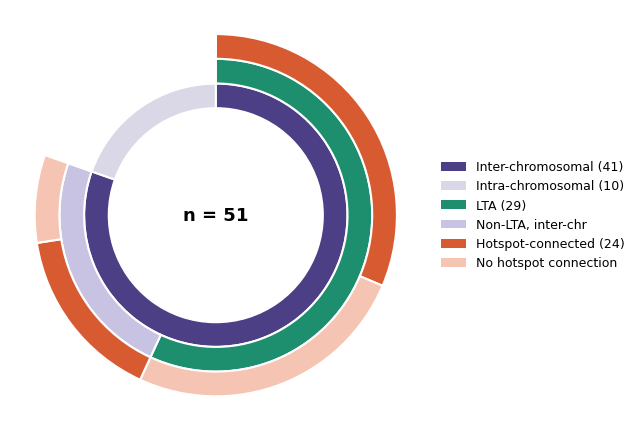

In [11]:
from matplotlib.patches import Patch

inter = lta_df['is_inter_chr']
lta   = lta_df['LTA']
hot   = lta_df['connected_other_hotspot']

# four joint cells within inter, ordered so each group leads with hotspot
b = lta_df.loc[inter &  lta &  hot, 'sample'].nunique()   # LTA + hotspot
print("LTA + hotspot", b)
a = lta_df.loc[inter &  lta & ~hot, 'sample'].nunique()   # LTA, no hotspot
print("LTA, no hotspot", a)
c = lta_df.loc[inter & ~lta &  hot, 'sample'].nunique()   # non-LTA + hotspot
print("non-LTA + hotspot", c)
d = lta_df.loc[inter & ~lta & ~hot, 'sample'].nunique()   # non-LTA, no hotspot
print("non-LTA, no hotspot", d)
n_intra = lta_df.loc[~inter, 'sample'].nunique()
print("intra", n_intra)

total   = lta_df['sample'].nunique()
n_inter = a + b + c + d
n_lta   = a + b
n_hot   = b + c

assert n_inter + n_intra == total
assert not lta_df['sample'].duplicated().any(), "duplicate samples in lta_df"

C_INTER, C_INTRA   = '#4C3F86', '#DAD7E6'   # inner: inter vs intra
C_LTA,   C_NONLTA  = '#1D8E6E', '#C9C3E3'   # middle: LTA vs non-LTA (both inter)
C_HOT,   C_NOHOT   = '#D85A30', '#F5C4B3'   # outer: hotspot (strong) vs no-hotspot (light)
CLEAR = (1, 1, 1, 0)

W = 0.15
wp = dict(width=W, edgecolor='white', linewidth=1.5)
common = dict(startangle=90, counterclock=False, wedgeprops=wp)

fig, ax = plt.subplots(figsize=(6.5, 6.5))

# inner: inter vs intra  (spans 0.67–0.80, center hole = 0.67)
w_in = ax.pie([n_inter, n_intra], radius=0.80,
              colors=[C_INTER, C_INTRA], **common)[0]

# middle: LTA (b+a) then non-LTA inter (c+d), clear over intra  (0.82–0.95)
w_mid = ax.pie([b + a, c + d, n_intra], radius=0.95,
               colors=[C_LTA, C_NONLTA, CLEAR], **common)[0]

# outer: b,a,c,d then intra — alternates hotspot/no-hotspot per group  (0.97–1.10)
w_out = ax.pie([b, a, c, d, n_intra], radius=1.10,
               colors=[C_HOT, C_NOHOT, C_HOT, C_NOHOT, CLEAR], **common)[0]

def label(w, text, r, dark=False, min_deg=12):
    if (w.theta2 - w.theta1) < min_deg:   # skip labels on tiny wedges
        return
    ang = np.deg2rad((w.theta1 + w.theta2) / 2)
    ax.text(r*np.cos(ang), r*np.sin(ang), str(text), ha='center', va='center',
            fontsize=9, fontweight='bold', color='#333' if dark else 'white')
'''
label(w_in[0],  n_inter, 0.735)
label(w_in[1],  n_intra, 0.735, dark=True)
label(w_mid[0], n_lta,   0.885)
label(w_out[0], b, 1.035); label(w_out[1], a, 1.035, dark=True)
label(w_out[2], c, 1.035); label(w_out[3], d, 1.035, dark=True)
'''

ax.text(0, 0, f"n = {total}", ha='center', va='center', fontsize=13, fontweight='bold')

ax.legend(handles=[
    Patch(fc=C_INTER,  label=f'Inter-chromosomal ({n_inter})'),
    Patch(fc=C_INTRA,  label=f'Intra-chromosomal ({n_intra})'),
    Patch(fc=C_LTA,    label=f'LTA ({n_lta})'),
    Patch(fc=C_NONLTA, label='Non-LTA, inter-chr'),
    Patch(fc=C_HOT,    label=f'Hotspot-connected ({n_hot})'),
    Patch(fc=C_NOHOT,  label='No hotspot connection'),
], loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9)

ax.set(aspect='equal')
plt.tight_layout()
plt.savefig('../results/lta_pie_chart_v2.pdf', bbox_inches='tight')
plt.show()